# Summary

1. Load data from ```process_uber_summary``` table and build **all process (sub)trees of size 3 or more**
2. Load PID's embeddings obtained from numerical features (see notebook ```process_embeddings```)
3. Run our **fast matching** algorithm using:
   * process_name or file_md5 only
   * append cluster number from numerical features
   * actually use distance between numerical feature embeddings

### References

* https://github.com/llnl/Wintap-Analytics/tree/main/2025-acme4-explore
* https://gdo168.llnl.gov/
* https://gdo168.llnl.gov/data/newdocs/datadict/
  

# Introduction

The first few cells are taken from BH's ```process-name-curation``` notebook


In [1]:
%load_ext autoreload
%load_ext dotenv
#%load_ext quak 
%load_ext sql

Tip: You may define configurations in /work/home/fcthebe/Acme4/Forked/Wintap-Analytics/2025-acme4-explore/pyproject.toml or /work/home/fcthebe/.jupysql/config.

Did not find user configurations in /work/home/fcthebe/Acme4/Forked/Wintap-Analytics/2025-acme4-explore/pyproject.toml.

In [2]:
%autoreload 1
%aimport acme4_explore

In [3]:
%%time
import acme4_explore
import io
import logging as lg
import numpy as np
import os
import pandas as pd
import re
from tqdm.auto import tqdm, trange
from collections import Counter
import warnings
import pickle
import gzip

# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.metrics import adjusted_mutual_info_score as AMI
from scipy.spatial import distance
from sklearn.neighbors import NearestNeighbors
import random 

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz
import igraph as ig
import partition_igraph
import umap

# utility functions and matching algorithm
import process_trees as pt
import igraph_io as igio
import gw_matcher as gwm ## older code - for testing
import fast_match as fm  ## fast version


CPU times: user 6.43 s, sys: 208 ms, total: 6.64 s
Wall time: 3.48 s


In [4]:
# Registers the current `tqdm` class with pandas.core.
tqdm.pandas()


In [5]:
lg.basicConfig(**acme4_explore.logging_config())
LOG = lg.getLogger("notebook")


In [6]:
db = acme4_explore.connect_db()
%sql db --alias duckdb
%config SqlMagic.displaycon=False
%config SqlMagic.autopandas=True


# Generate or load process tree objects


In [7]:
## load df_trees and Trees
with gzip.open('Data/acme4_process_trees_and_df.pkl.gz', 'rb') as fp:
   Trees, df_trees =  pickle.load(fp)


#### Generate the **Trees** and related **df_trees** objects

Uncomment the cells below to generate; takes over 30 min


### load embeddings (based on numerical features) 

Those are dictionaries with key=PID, value=embedding as an array, built in notebook ```process_embedding.ipynb```


In [8]:
with gzip.open('Data/acme4_process_num_features_embedding_scaled.pkl.gz', 'rb') as fp:
    Embedding_scaled = pickle.load(fp)
with gzip.open('Data/acme4_process_num_features_embedding_ecdf.pkl.gz', 'rb') as fp:
    Embedding_ecdf = pickle.load(fp)


### Add inverse frequency score

* We will also compute an inverse-frequency score as post-processing for the matching algorithm (sum of inverse frequency of matched processes)
* Useful to find matchings over "less common" processes


In [9]:
proc_counts = Counter(Trees.graph.vs['process'])
InvFreq = {k: 1/np.log2(v+1) for k, v in proc_counts.items()} ## max score of 1 when v==1


# Matching algorithm

## (1) Simple experiment -- using a single base (template) tree

We consider three scores:
* matching algorithm: number of matching process names
* similarity score: 1 - mean distance in embedded space of matching PIDs
* inv_freq_score: sum of inverse frequencies of matching processes


In [10]:
%%time

feature_to_match = 'process'
min_score = 5 ## min matching score to consider
max_size = 500 ## max tree size to consider for comparison

## base tree
sg1 = pt.get_bfs_subtree(Trees, tree_id=27, root_id=27)
print('base tree size:', sg1.vcount())

## initialize list of trees and encoded trees for fast matching
Graphs = [sg1]
TreeData = [igio.igraph_to_treedata(sg1, phi_name=feature_to_match)]

## add the trees to compare
_df = df_trees[ (df_trees.layers >= min_score) & (df_trees.nodes <= max_size) ] 
T = list(_df.tree)
R = list(_df.root)
L = list(_df.layers)
dim = len(next(iter(Embedding_ecdf.values())))

print('number of subtrees to compare:',len(T))
for i in range(len(T)):
    sg2 = pt.get_bfs_subtree(Trees, T[i], R[i])
    Graphs.append(sg2)
    TreeData.append(igio.igraph_to_treedata(sg2, phi_name=feature_to_match))

## encode all trees
fast = fm.FastTreePathMatcher()
fast.fit_encoder(TreeData)
enc = [fast.encode_tree(t) for t in TreeData]

## score every tree
Results = []
for i in range(len(T)):
    paths, score = fast.predict_encoded(enc[0], enc[i+1])
    if score >= min_score:
        sg2 = Graphs[i+1]
        path = [x[1] for x in paths]
        freq_score = sum([InvFreq[sg2.vs[v]['process']] for v in path])
        bu = sum(1 for item in [sg2.vs[j]['username'] for j in path] if isinstance(item, str) and 'baduser' in item)
        sim = np.mean([1-distance.cityblock( Embedding_ecdf[sg1.vs[x[0]]['pid']] , Embedding_ecdf[sg2.vs[x[1]]['pid']] )/dim for x in paths])
        Results.append([T[i],R[i],L[i],sg2.vcount(),sg2.vs[0]['process'],int(score), sim, freq_score, bu])

results_df = pd.DataFrame(Results, columns=['tree','root','layers','nodes','process','score','sim_ecdf', 'inv_freq_score', 'badusers'])
results_df['freq_ratio'] = results_df.inv_freq_score / results_df.score
_T = list(results_df.tree)
_R = list(results_df.root)
results_df['parent'] = [pt.get_parent(Trees, _T[i], _R[i]) for i in range(len(_T))]


base tree size: 200
number of subtrees to compare: 498
CPU times: user 53.6 s, sys: 197 ms, total: 53.8 s
Wall time: 53.8 s


In [11]:
## results with long matches and high embedding similarity
results_df.sort_values(by=['score', 'sim_ecdf'], ascending=False).head(10)


,tree,root,layers,nodes,process,score,sim_ecdf,inv_freq_score,badusers,freq_ratio,parent
92,27,27,9,200,smss.exe,9,1.000000,1.498744,7,0.166527,345
93,27,28,8,198,winlogon.exe,8,1.000000,1.370232,7,0.171279,27
52,16,523,13,161,smss.exe,8,0.985350,1.039325,0,0.129916,405
98,27,365,9,106,smss.exe,8,0.945918,1.039325,3,0.129916,345
38,11,397,8,77,smss.exe,8,0.943203,1.443574,0,0.180447,0
99,27,561,7,192,userinit.exe,7,1.000000,1.237454,7,0.176779,28
46,16,5,12,159,winlogon.exe,7,0.986488,0.910813,0,0.130116,523
39,11,398,7,75,winlogon.exe,7,0.944493,1.315062,0,0.187866,397
91,27,16,8,104,winlogon.exe,7,0.940418,0.910813,3,0.130116,365
141,75,10,8,97,conhost.exe,7,0.934287,0.910813,0,0.130116,94


In [12]:
## pick one and visualize common path
sg2 = pt.get_bfs_subtree(Trees, 16, 523)
_sg2 = igio.igraph_to_treedata(sg2, phi_name='process')
_sg1 = igio.igraph_to_treedata(sg1, phi_name='process')
fast = fm.FastTreePathMatcher()
fast.fit(_sg1,_sg2)
paths, score = fast.predict()


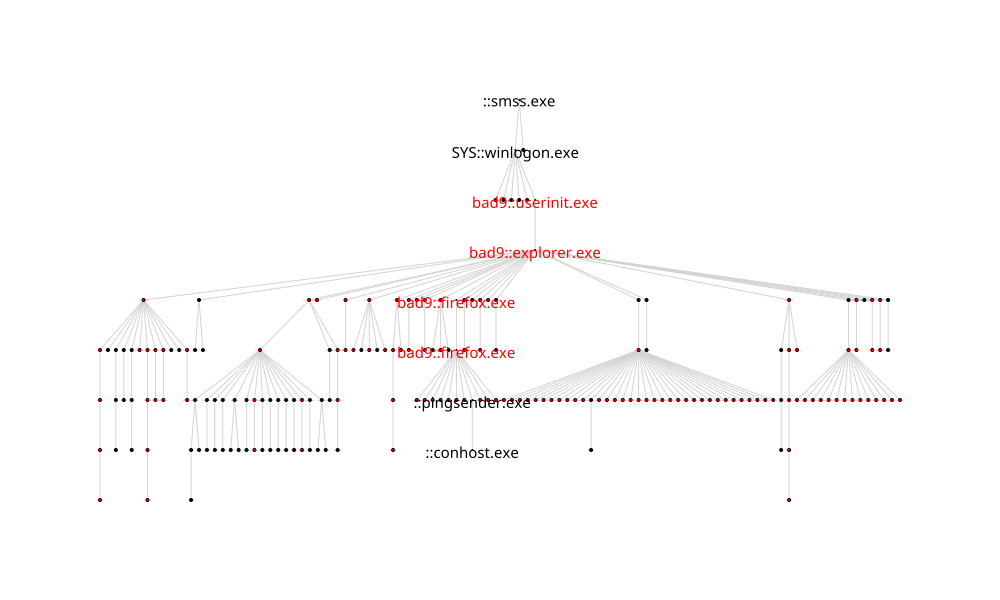

In [13]:
## plot reference tree (with baduser)
path = [int(x[0]) for x in paths]
sg1.vs['vertex_size'] = 3
sg1.vs['vertex_label_size'] = 1
for i in path:
    sg1.vs[i]['vertex_size'] = 1
    sg1.vs[i]['vertex_label_size'] = 15
ig.plot(sg1,
        bbox=(1000,600), layout=sg1['ly'], margin=100, 
        vertex_size=sg1.vs['vertex_size'], 
        vertex_label=sg1.vs['label'], 
        vertex_label_size=sg1.vs['vertex_label_size'], 
        edge_color='lightgrey', edge_arrow_size=0)


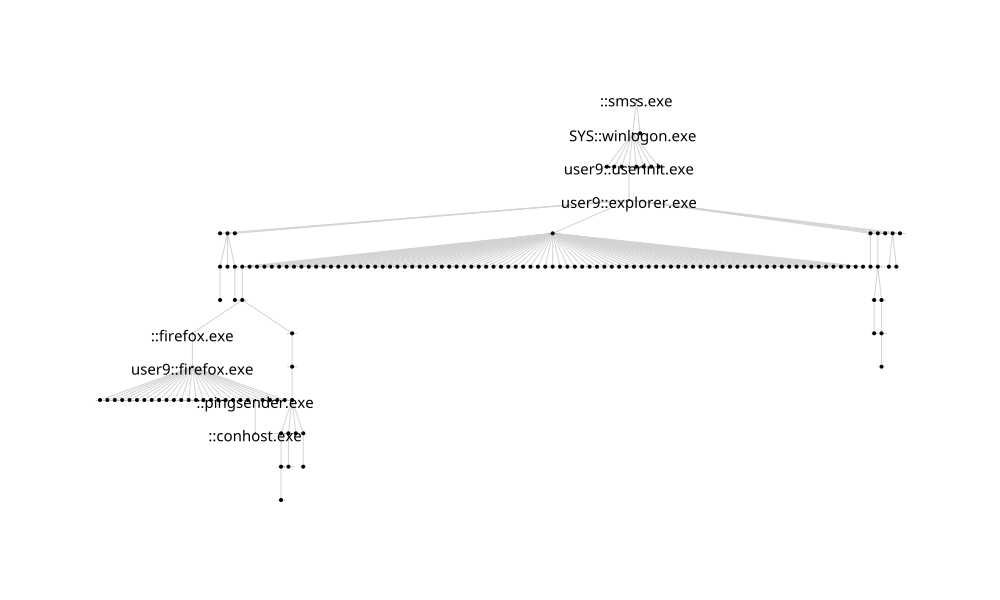

In [14]:
## plot top scoring tree
path = [int(x[1]) for x in paths]
sg2.vs['vertex_size'] = 3
sg2.vs['vertex_label_size'] = 1
for i in path:
    sg2.vs[i]['vertex_size'] = 1
    sg2.vs[i]['vertex_label_size'] = 15
ig.plot(sg2,
        bbox=(1000,600), layout=sg2['ly'], margin=100, 
        vertex_size=sg2.vs['vertex_size'], 
        vertex_label=sg2.vs['label'], 
        vertex_label_size=sg2.vs['vertex_label_size'], 
        edge_color='lightgrey', edge_arrow_size=0)


#### Compare embeddings of pairwise processes


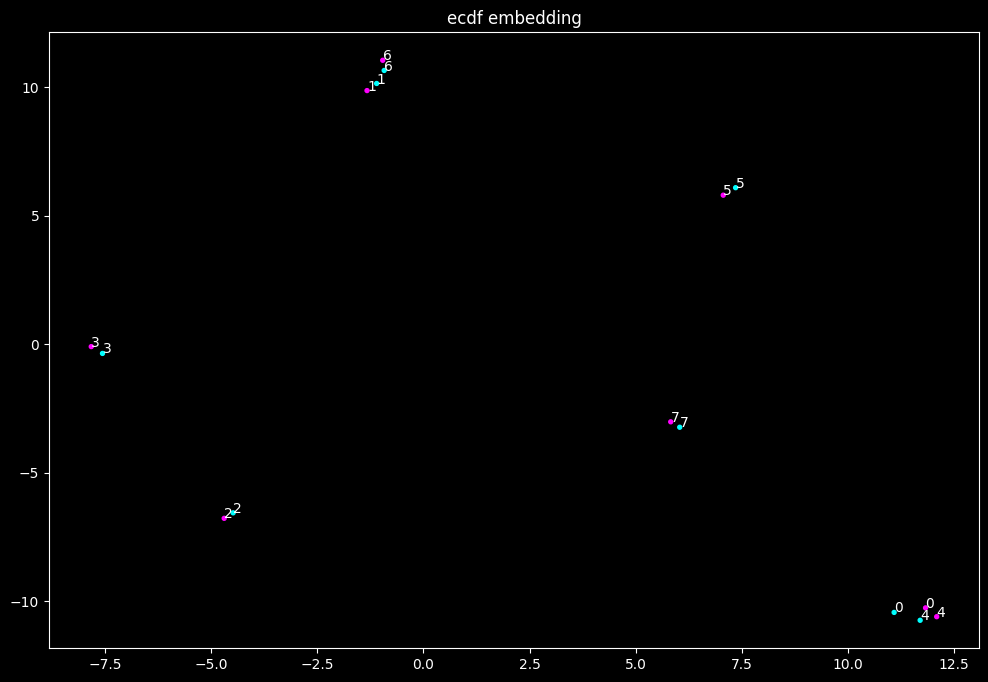

In [15]:
path0 = [int(x[0]) for x in paths]
path1 = [int(x[1]) for x in paths]
l = len(path0)
c = np.repeat([0,1],l)
s = np.tile(np.arange(l),2)
X = []
for i in path0:
    X.append(Embedding_ecdf[sg1.vs[i]['pid']])
for i in path1:
    X.append(Embedding_ecdf[sg2.vs[i]['pid']])

## 2d projection
reducer = umap.UMAP(n_neighbors=2, metric='manhattan')
embedding = reducer.fit_transform(np.array(X))

# plot it - color w.r.t. response variable (bad/nonbad)
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12,8))
ax.scatter(embedding[:, 0], embedding[:, 1], s=8, c=c, cmap='cool')
ax.set_title('ecdf embedding')
for i in range(embedding.shape[0]):
    ax.annotate(s[i], (embedding[i, 0], embedding[i, 1]))
plt.show()


In [16]:
## look for matches over less common processes, exclude template tree itself this time
results_df[(results_df.tree != 27)].sort_values(by=['freq_ratio'], ascending=False).head(10)


,tree,root,layers,nodes,process,score,sim_ecdf,inv_freq_score,badusers,freq_ratio,parent
41,11,1927,5,66,explorer.exe,5,0.941601,1.023649,0,0.204730,1069
40,11,1069,6,67,userinit.exe,6,0.950564,1.182284,0,0.197047,398
39,11,398,7,75,winlogon.exe,7,0.944493,1.315062,0,0.187866,397
38,11,397,8,77,smss.exe,8,0.943203,1.443574,0,0.180447,0
11,1,27185,8,9,smss.exe,5,0.825436,0.668027,0,0.133605,0
46,16,5,12,159,winlogon.exe,7,0.986488,0.910813,0,0.130116,523
141,75,10,8,97,conhost.exe,7,0.934287,0.910813,0,0.130116,94
142,75,11,7,96,winlogon.exe,7,0.934287,0.910813,0,0.130116,10
52,16,523,13,161,smss.exe,8,0.985350,1.039325,0,0.129916,405
53,16,1075,11,151,userinit.exe,6,0.985821,0.778035,0,0.129673,5


In [17]:
## pick one and visualize common path
sg2 = pt.get_bfs_subtree(Trees, 11, 1927)
_sg2 = igio.igraph_to_treedata(sg2, phi_name='process')
_sg1 = igio.igraph_to_treedata(sg1, phi_name='process')
fast = fm.FastTreePathMatcher()
fast.fit(_sg1,_sg2)
paths, score = fast.predict()


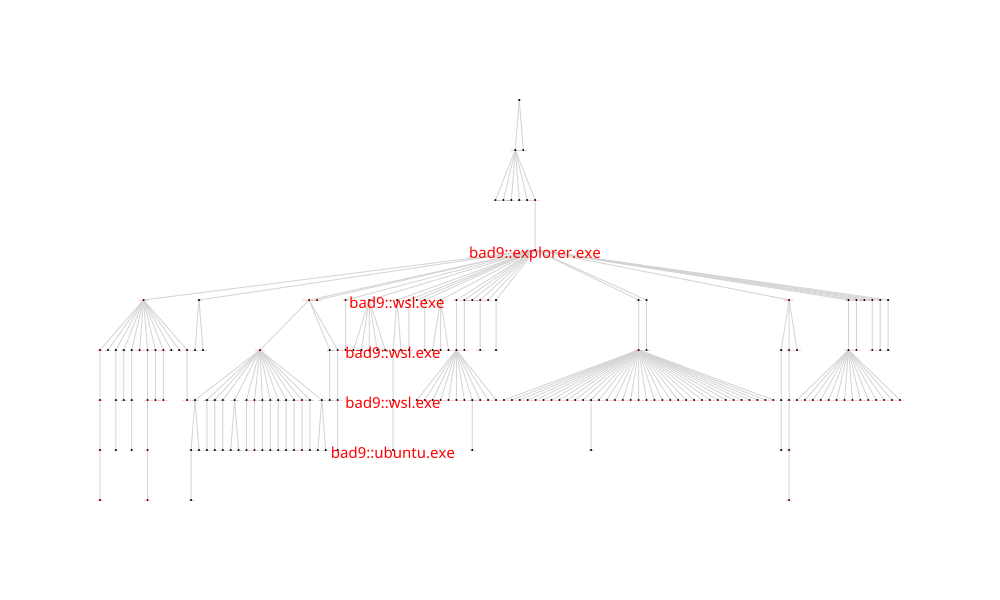

In [18]:
## plot reference tree (with baduser)
path = [int(x[0]) for x in paths]
sg1.vs['vertex_size'] = 1
sg1.vs['vertex_label_size'] = 1
for i in path:
    sg1.vs[i]['vertex_size'] = 1
    sg1.vs[i]['vertex_label_size'] = 15
ig.plot(sg1,
        bbox=(1000,600), layout=sg1['ly'], margin=100, 
        vertex_size=sg1.vs['vertex_size'], 
        vertex_label=sg1.vs['label'], 
        vertex_label_size=sg1.vs['vertex_label_size'], 
        edge_color='lightgrey', edge_arrow_size=0)


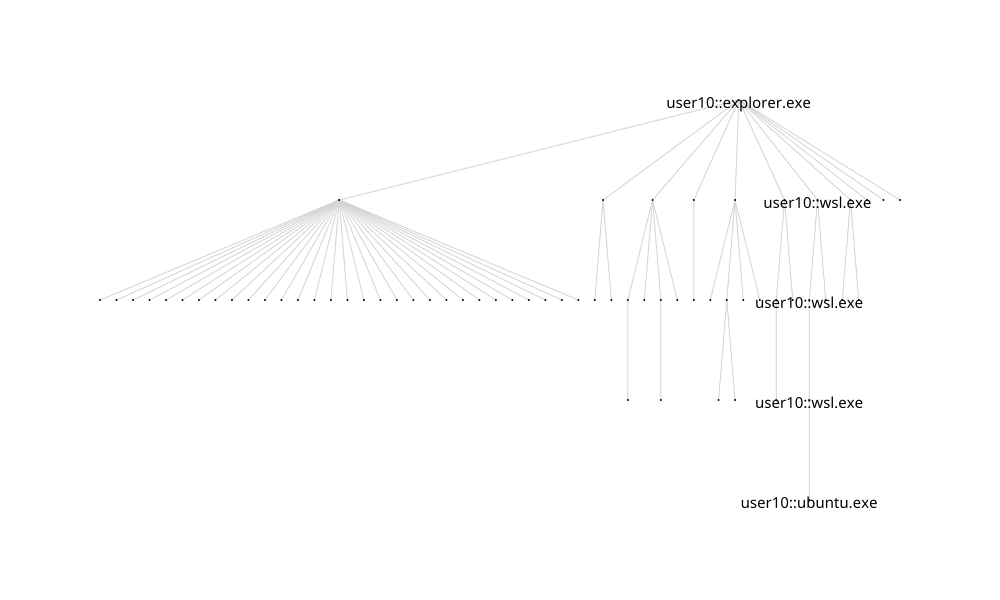

In [19]:
## plot top scoring tree
path = [int(x[1]) for x in paths]
sg2.vs['vertex_size'] = 1
sg2.vs['vertex_label_size'] = 0
for i in path:
    sg2.vs[i]['vertex_size'] = 1
    sg2.vs[i]['vertex_label_size'] = 15
ig.plot(sg2,
        bbox=(1000,600), layout=sg2['ly'], margin=100, 
        vertex_size=sg2.vs['vertex_size'], 
        vertex_label=sg2.vs['label'], 
        vertex_label_size=sg2.vs['vertex_label_size'], 
        edge_color='lightgrey', edge_arrow_size=0)


## (2) Enrich labels via clustering

* clusters in embedded space we already have
* clusters from BH


In [221]:
## get embeddings 
A = np.array(list(Embedding_ecdf.values()))
avg_emb = np.mean(A, axis=0)
Pids = Trees.graph.vs['pid']
E = np.array([Embedding_ecdf.get(x,avg_emb) for x in Pids]) ## some roots (parents only) have no embedding


In [222]:
## fast clustering
from sklearn.cluster import MiniBatchKMeans
mbk = MiniBatchKMeans(n_clusters=64, batch_size=1024, n_init="auto", random_state=42)
mbk.fit(E)
cluster_dct = dict(zip(Pids,mbk.labels_))
G = Trees.graph
G.vs['cluster'] = [str(i) for i in mbk.labels_] 


In [223]:
## Using cluster labels from B.H.
_ = pd.read_parquet('/data/ACME4/labels-benoit-202510.parquet')
_dct = {v:k for k,v in enumerate(list(set(_['label'])))}
bh_labels = dict(zip(_.pid_hash,[_dct[i] for i in _.label]))
bh_mapping = {v:k for k,v in enumerate(_dct)}
## add enriched label process+cluster
G = Trees.graph
G.vs['bh'] = [bh_labels.get(v,-1) for v in G.vs['pid']]


In [387]:
## add enriched label process+cluster+bh
G.vs['enriched'] = [f"{a}_{b}_{c}" for a, b, c in zip(G.vs['process'], G.vs['cluster'], G.vs['bh'])]
G.vs['enriched_label'] = [f"{a}::{b}" for a, b in zip(G.vs['shortlabel'], G.vs['enriched'])]

## add enriched label process+bh
# G.vs['enriched'] = [f"{a}_{b}" for a, b in zip(G.vs['process'], G.vs['bh'])]
# G.vs['enriched_label'] = [f"{a}::{b}" for a, b in zip(G.vs['shortlabel'], G.vs['enriched'])]

## add enriched label process+bh
# G.vs['enriched'] = [f"{a}_{b}" for a, b in zip(G.vs['process'], G.vs['cluster'])]
# G.vs['enriched_label'] = [f"{a}::{b}" for a, b in zip(G.vs['shortlabel'], G.vs['enriched'])]


In [270]:
%%time

feature_to_match = 'enriched'
min_score = 4 ## min matching score to consider
max_size = 500 ## max tree size to consider for comparison

## base tree
sg1 = pt.get_bfs_subtree(Trees, tree_id=27, root_id=27)
print('base tree size:', sg1.vcount())

## initialize list of trees and encoded trees for fast matching
Graphs = [sg1]
TreeData = [igio.igraph_to_treedata(sg1, phi_name=feature_to_match)]

## add the trees to compare
_df = df_trees[ (df_trees.layers >= min_score) & (df_trees.nodes <= max_size) ] 
T = list(_df.tree)
R = list(_df.root)
L = list(_df.layers)
dim = len(next(iter(Embedding_ecdf.values())))

print('number of subtrees to compare:',len(T))
for i in range(len(T)):
    sg2 = pt.get_bfs_subtree(Trees, T[i], R[i])
    Graphs.append(sg2)
    TreeData.append(igio.igraph_to_treedata(sg2, phi_name=feature_to_match))

## encode all trees
fast = fm.FastTreePathMatcher()
fast.fit_encoder(TreeData)
enc = [fast.encode_tree(t) for t in TreeData]

## score every tree
Results = []
for i in range(len(T)):
    paths, score = fast.predict_encoded(enc[0], enc[i+1])
    if score >= min_score:
        sg2 = Graphs[i+1]
        path = [x[1] for x in paths]
        freq_score = sum([InvFreq[sg2.vs[v]['process']] for v in path])
        bu = sum(1 for item in [sg2.vs[j]['username'] for j in path] if isinstance(item, str) and 'baduser' in item)
        bh = sum([sg2.vs[i]['bh']>=0 for i in path])
        sim = np.mean([1-distance.cityblock( Embedding_ecdf[sg1.vs[x[0]]['pid']] , Embedding_ecdf[sg2.vs[x[1]]['pid']] )/dim for x in paths])
        Results.append([T[i],R[i],L[i],sg2.vcount(),sg2.vs[0]['process'],int(score), sim, freq_score, bh, bu])

results_df = pd.DataFrame(Results, columns=['tree','root','layers','nodes','process','score','sim_ecdf', 'inv_freq_score', 'bh', 'badusers'])
results_df['freq_ratio'] = results_df.inv_freq_score / results_df.score
_T = list(results_df.tree)
_R = list(results_df.root)
results_df['parent'] = [pt.get_parent(Trees, _T[i], _R[i]) for i in range(len(_T))]


base tree size: 200
number of subtrees to compare: 1005
CPU times: user 1min 45s, sys: 65.2 ms, total: 1min 45s
Wall time: 1min 45s


In [279]:
## results with long matches and high embedding similarity
results_df[ (results_df.bh>1) & (results_df.sim_ecdf>.8) ].sort_values(by=['score', 'sim_ecdf'], ascending=False).head()


,tree,root,layers,nodes,process,score,sim_ecdf,inv_freq_score,bh,badusers,freq_ratio,parent
12,1,4475,13,124,smss.exe,7,0.880513,0.808825,2,0,0.115546,0
13,1,4476,12,122,winlogon.exe,6,0.873321,0.680313,2,0,0.113386,4475
16,1,11858,11,117,userinit.exe,5,0.871819,0.547535,2,0,0.109507,4476
9,1,196,10,116,explorer.exe,4,0.849414,0.388901,2,0,0.097225,11858


In [280]:
## pick one and visualize common path
sg2 = pt.get_bfs_subtree(Trees, 1, 4475)
_sg2 = igio.igraph_to_treedata(sg2, phi_name='enriched')
_sg1 = igio.igraph_to_treedata(sg1, phi_name='enriched')
fast = fm.FastTreePathMatcher()
fast.fit(_sg1,_sg2)
paths, score = fast.predict()


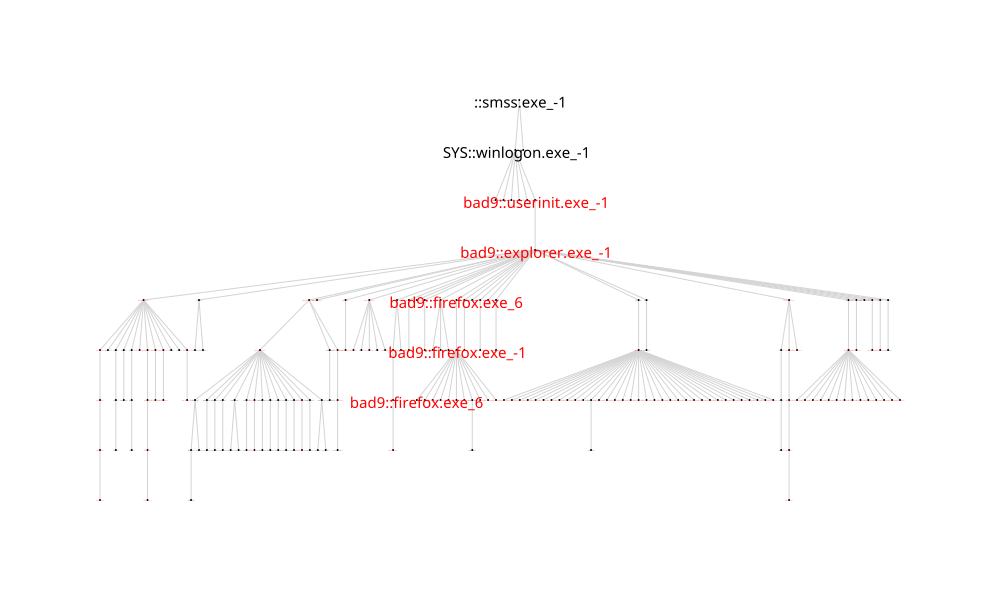

In [281]:
## plot reference tree (with baduser)
path = [int(x[0]) for x in paths]
sg1.vs['vertex_size'] = 1
sg1.vs['vertex_label_size'] = 1
for i in path:
    sg1.vs[i]['vertex_size'] = 1
    sg1.vs[i]['vertex_label_size'] = 15
ig.plot(sg1,
        bbox=(1000,600), layout=sg1['ly'], margin=100, 
        vertex_size=sg1.vs['vertex_size'], 
        vertex_label=sg1.vs['enriched_label'], 
        vertex_label_size=sg1.vs['vertex_label_size'], 
        edge_color='lightgrey', edge_arrow_size=0)


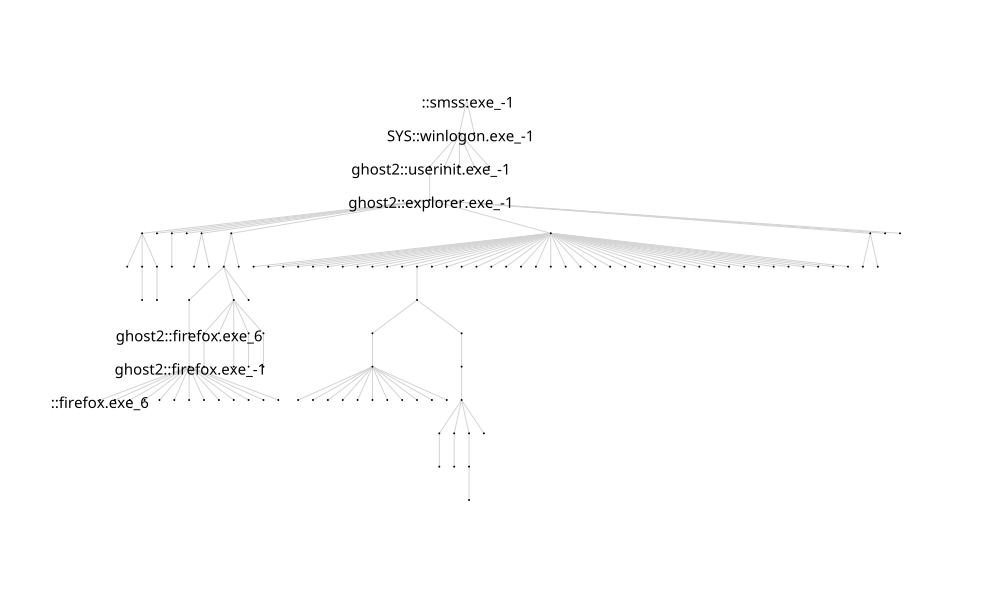

In [282]:
## plot top scoring tree
path = [int(x[1]) for x in paths]
sg2.vs['vertex_size'] = 1
sg2.vs['vertex_label_size'] = 0
for i in path:
    sg2.vs[i]['vertex_size'] = 1
    sg2.vs[i]['vertex_label_size'] = 15
ig.plot(sg2,
        bbox=(1000,600), layout=sg2['ly'], margin=100, 
        vertex_size=sg2.vs['vertex_size'], 
        vertex_label=sg2.vs['enriched_label'], 
        vertex_label_size=sg2.vs['vertex_label_size'], 
        edge_color='lightgrey', edge_arrow_size=0)


## (3) Using several templates

We run a classifiction experiment on 4 common root process names

In [156]:
### filter subtrees 
_df = df_trees[(df_trees.nodes<=5000) & (df_trees.layers>=3)]
Counter(_df.process).most_common(10)


[('bash.exe', 507),
 ('taskhostw.exe', 500),
 ('cmd.exe', 264),
 ('smss.exe', 189),
 ('setup.exe', 113),
 ('powershell.exe', 106),
 ('explorer.exe', 79),
 ('winlogon.exe', 78),
 ('userinit.exe', 77),
 ('microsoftedgeupdate.exe', 71)]

In [157]:
n_class = 5
n_templates = 50

common_proc = [x[0] for x in Counter(_df.process).most_common(n_class)]
_df = _df[_df.process.isin(common_proc)]

## random templates
min_rep = 0
np.random.seed(123)
while min_rep < 9:
    r = np.random.choice(_df.shape[0], n_templates, replace=False)
    proc = [list(_df.process)[i] for i in r]
    if len(set(proc)) < n_class:
        continue        
    min_rep = min(Counter(proc).values())
templates = [(list(_df.tree)[i],list(_df.root)[i]) for i in r]
Counter(proc)


Counter({'taskhostw.exe': 14,
         'cmd.exe': 9,
         'bash.exe': 9,
         'smss.exe': 9,
         'setup.exe': 9})

In [123]:
%%time
## build similarity matrix between all trees and templates
Graphs = []
TreeData = []
T = list(_df.tree)
R = list(_df.root)
l = len(templates)
Sim = np.zeros(shape=(l, len(T)))
Score = np.zeros(shape=(l, len(T)))
dim = len(next(iter(Embedding_ecdf.values())))

## list all template graphs
for tree,root in templates:
    sg1 = pt.get_bfs_subtree(Trees, tree, root) ## sub-tree above with required DFS labelling
    Graphs.append(sg1)
    TreeData.append(igio.igraph_to_treedata(sg1, phi_name='process'))
## add trees to be compared 
for j in range(len(T)):
    sg2 = pt.get_bfs_subtree(Trees, T[j], R[j])
    Graphs.append(sg2)
    TreeData.append(igio.igraph_to_treedata(sg2, phi_name='process'))

## encode all trees
fast = fm.FastTreePathMatcher()
fast.fit_encoder(TreeData)
enc = [fast.encode_tree(t) for t in TreeData]

for i in range(l):
    for j in range(len(T)):
        paths, score = fast.predict_encoded(enc[i], enc[j+l])
        Score[i,j] = score
        if score>0:
            # print(i, j, paths)
            sim = np.mean([1-distance.cityblock( Embedding_ecdf[Graphs[i].vs[x[0]]['pid']] , Embedding_ecdf[Graphs[j+l].vs[x[1]]['pid']] )/dim for x in paths])
        else:
            sim = 0
        Sim[i,j] = sim
        

CPU times: user 2min 7s, sys: 629 ms, total: 2min 7s
Wall time: 2min 7s


In [124]:
label_map = {v:k for k,v in enumerate(common_proc)}
X = Score.T.tolist()
y = [label_map[i] for i in _df.process]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=123)
rf = RandomForestClassifier(n_jobs=16, random_state=123)
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


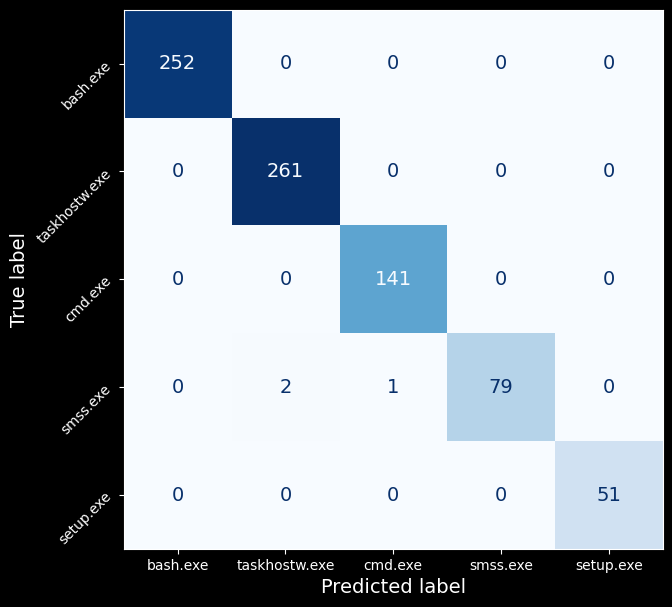

In [127]:
## confusion matrix
y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test,y_pred)
fig,ax = plt.subplots(figsize=(9,7))
plt.rcParams.update({'font.size': 14}) # Change to your desired size
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=list(label_map.keys())
                             )
disp.plot(colorbar=False, cmap='Blues', ax=ax)
plt.xticks(fontsize=10)
plt.yticks(rotation=45, fontsize=10)
plt.show()


In [128]:
label_map = {v:k for k,v in enumerate(common_proc)}
X = (Sim).T.tolist()
y = [label_map[i] for i in _df.process]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=123)
rf = RandomForestClassifier(n_jobs=16, random_state=123)
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


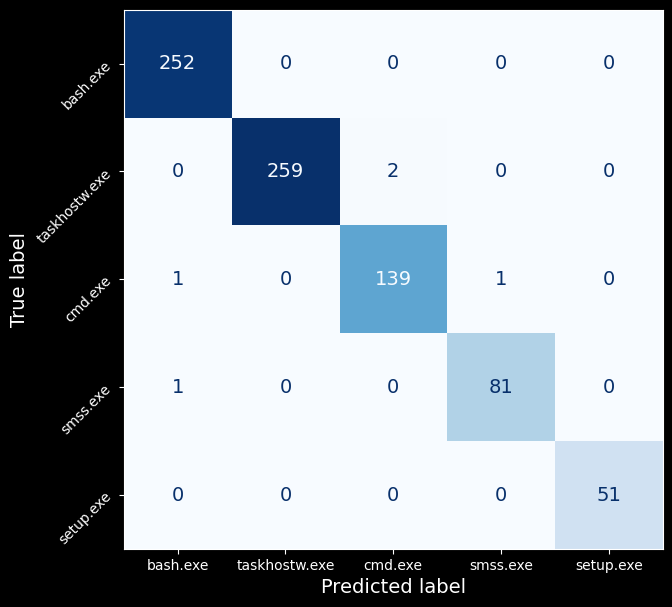

In [129]:
## confusion matrix
y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test,y_pred)
fig,ax = plt.subplots(figsize=(9,7))
plt.rcParams.update({'font.size': 14}) # Change to your desired size
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=list(label_map.keys())
                             )
disp.plot(colorbar=False, cmap='Blues', ax=ax)
plt.xticks(fontsize=10)
plt.yticks(rotation=45, fontsize=10)
plt.show()


In [86]:
## root processes' embeddings
E = []
C = []
for t,r in zip(list(_df.tree),list(_df.root)):
    v = Trees.subgraph(t).vs[r]
    E.append(Embedding_ecdf[v['pid']])
    C.append(v['process'])
Clusters = np.array(C)
Embs = np.array(E)


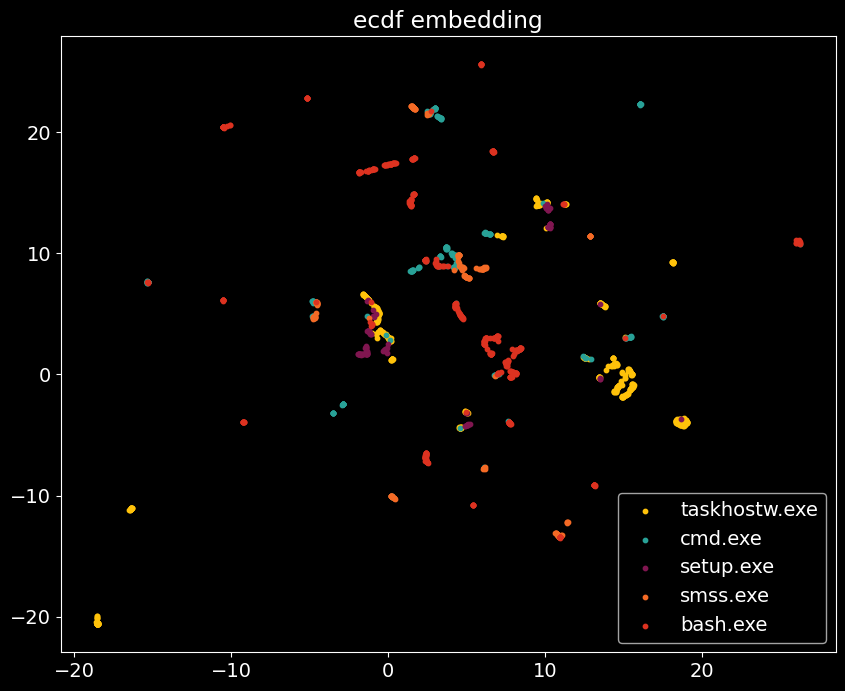

In [88]:
## plot
reducer = umap.UMAP(n_neighbors=15, metric='manhattan', init='random', random_state=123, n_jobs=1)
embedding = reducer.fit_transform(E)

# plot it - color w.r.t. response variable (bad/nonbad)
plt.style.use('dark_background')
plt.figure(figsize=(10,8))
_dct = {v:k for k,v in enumerate(set(C))}
colors = ['#FFC20A','#28A197','#801650','#F46A25','#DC3220']

for c, l in enumerate(_dct):
    plt.scatter(embedding[Clusters==l, 0], embedding[Clusters==l, 1], s=10, c=colors[c], label=l)
plt.title('ecdf embedding')
plt.legend()
plt.show()


## (4) kNN graph clustering with ECG

In [142]:
## scaled mixed score 
scaler = StandardScaler()
X = scaler.fit_transform(((Score+1)*Sim).T)

# fit
knn = NearestNeighbors(n_neighbors=11, metric='minkowski', p=1)
knn.fit(X)
K = knn.kneighbors(X)[1]


In [143]:
## build graph
_dict = {i: row for i, row in enumerate(K)}
G = ig.Graph.ListDict(_dict)
G = G.simplify()
G.vs['label'] = [str(i) for i in Clusters] ## Clusters from previous experiment
G.summary()


'IGRAPH U--- 1573 10737 -- \n+ attr: label (v)'

In [144]:
## add colors based on root process
_dct = {v:k for k,v in enumerate(set(Clusters))}
colors = ['#FFC20A','#28A197','#801650','#F46A25','#DC3220']
G.vs['color'] = [colors[_dct[i]] for i in Clusters]

## plot with GT colors
random.seed(42)
ly = G.layout_fruchterman_reingold()
ig.plot(G, vertex_size=5, vertex_label_size=0, edge_color='grey', layout=ly)


In [148]:
## ECG clustering
np.random.seed(42)
random.seed(42)
GCC = G.community_ecg(ens_size=100, resolution=.05, final='leiden')
print(GCC.summary())
print('AMI:',AMI(GCC.membership, G.vs['label']))


Clustering with 1573 elements and 22 clusters
AMI: 0.673173778971511


In [149]:
## plot
cmap = plt.get_cmap('tab20')
colors = [plt.cm.colors.to_hex(cmap(i)) for i in range(max(GCC.membership)+1)]
G.es['w'] = GCC.W
G.es['color'] = 'grey'
G.es['width'] = [1 if e['w']>.05 else 0 for e in G.es ]
ig.plot(GCC, vertex_size=5, vertex_label_size=0, layout=ly, vertex_color=[colors[i] for i in GCC.membership], mark_groups=True)


In [155]:
## cluster composition
__df = pd.DataFrame({'process':G.vs['label'], 'cluster':GCC.membership})
__df.groupby(by='cluster')['process'].value_counts()


cluster  process      
0        taskhostw.exe    253
         smss.exe           1
1        smss.exe          33
2        setup.exe        113
         smss.exe           2
3        smss.exe          78
4        cmd.exe           84
5        taskhostw.exe    127
6        cmd.exe           69
7        bash.exe          84
8        bash.exe          39
9        smss.exe          47
10       taskhostw.exe    120
11       cmd.exe           47
         smss.exe           1
12       bash.exe          99
13       bash.exe         134
14       bash.exe          53
15       bash.exe          33
16       cmd.exe           64
17       smss.exe          14
18       smss.exe          13
19       bash.exe          17
20       bash.exe          31
21       bash.exe          17
Name: count, dtype: int64

In [200]:
## Cluster X directly
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

max_sil = -1
for ncl in np.arange(3,31,1):
    clst = KMeans(n_clusters=22)
    lbls = clst.fit_predict(X)
    s = silhouette_score(X, lbls)
    if s > max_sil:
        max_sil = s
        n_clusters = ncl

clst = KMeans(n_clusters=n_clusters)
lbls = clst.fit_predict(X)
__df = pd.DataFrame({'process':G.vs['label'], 'cluster':lbls})
__df.groupby(by='cluster')['process'].value_counts()


cluster  process      
0        bash.exe         140
1        taskhostw.exe    500
2        setup.exe        107
3        smss.exe         105
4        cmd.exe           64
5        smss.exe           4
6        smss.exe           6
7        cmd.exe           64
8        bash.exe         152
9        setup.exe          6
         smss.exe           1
10       cmd.exe           28
11       smss.exe          43
12       bash.exe          17
13       bash.exe           5
14       bash.exe          25
15       cmd.exe           19
16       smss.exe           5
17       cmd.exe           16
18       cmd.exe           70
19       bash.exe         167
20       cmd.exe            3
         bash.exe           1
21       smss.exe          25
Name: count, dtype: int64

In [308]:
df_trees

,tree,root,process,nodes,layers,leaves,bad3,bad9,bad25,splits,distribution,badusers
0,0,9,compattelrunner.exe,5,2,4,0,0,0,1,"[1, 4]",0
1,0,44,taskhostw.exe,9,3,6,0,0,0,3,"[1, 2, 6]",0
2,0,86,compattelrunner.exe,5,2,4,0,0,0,1,"[1, 4]",0
3,0,92,firefox.exe,665,2,664,0,0,0,1,"[1, 664]",0
4,0,95,ngentask.exe,4,2,3,0,0,0,1,"[1, 3]",0
...,...,...,...,...,...,...,...,...,...,...,...,...
5755,213,157,tad.exe,5,2,4,0,0,0,1,"[1, 4]",0
5756,217,0,ntoskrnl.exe,4,2,3,0,0,0,1,"[1, 3]",0
5757,221,0,ntoskrnl.exe,4,2,3,0,0,0,1,"[1, 3]",0
5758,222,0,ntoskrnl.exe,3,2,2,0,0,0,1,"[1, 2]",0


In [349]:
## Several templates with bad
_ = df_trees[(df_trees['badusers']>0) & (df_trees.nodes<=200) & (df_trees['layers']>=3)]
template_trees = list(_['tree'])
template_roots = list(_['root'])
n_templates = len(template_roots)


In [350]:
## Other trees w/o bad
_ = df_trees[(df_trees['badusers']==0) & (df_trees.nodes<=200) & (df_trees['layers']>=5)]
other_trees = list(_['tree'])
other_roots = list(_['root'])
n_others = len(other_roots)


In [389]:
%%time
Graphs = []
TreeData = []
## list all template graphs
for tree,root in zip(template_trees,template_roots):
    sg1 = pt.get_bfs_subtree(Trees, tree, root) 
    Graphs.append(sg1)
    TreeData.append(igio.igraph_to_treedata(sg1, phi_name='enriched'))
## add trees to be compared 
for tree,root in zip(other_trees,other_roots):
    sg2 = pt.get_bfs_subtree(Trees, tree, root) 
    Graphs.append(sg2)
    TreeData.append(igio.igraph_to_treedata(sg2, phi_name='enriched'))


CPU times: user 52.1 s, sys: 36.6 ms, total: 52.2 s
Wall time: 52.2 s


In [390]:
%%time
## encode all trees
fast = fm.FastTreePathMatcher()
fast.fit_encoder(TreeData)
enc = [fast.encode_tree(t) for t in TreeData]


CPU times: user 34.4 ms, sys: 2.97 ms, total: 37.3 ms
Wall time: 37 ms


In [391]:
%%time
print('number of computations:',n_templates*n_others)
Sim = np.zeros(shape=(n_templates, n_others))
Score = np.zeros(shape=(n_templates, n_others))
dim = len(next(iter(Embedding_ecdf.values())))
for i in range(n_templates):
    for j in range(n_others):
        paths, score = fast.predict_encoded(enc[i], enc[j+n_templates])
        Score[i,j] = score
        if score>0:
            sim = np.mean([1-distance.cityblock( Embedding_ecdf[Graphs[i].vs[x[0]]['pid']] , Embedding_ecdf[Graphs[j+n_templates].vs[x[1]]['pid']] )/dim for x in paths])
        else:
            sim = 0
        Sim[i,j] = sim


number of computations: 35112
CPU times: user 1.06 s, sys: 0 ns, total: 1.06 s
Wall time: 1.06 s


In [394]:
## tree with multi template matches
np.where( (Score>=5).sum(axis=0) >= 2 )

(array([  3,   7,  83,  86, 135, 144, 202, 203, 223, 227, 253, 254, 257,
        264, 358, 359, 361]),)

In [417]:
## which templates
np.where(Score[:,358]>=5)

(array([32, 55, 69]),)

In [424]:
## pick one and visualize common path
sg1 = pt.get_bfs_subtree(Trees, other_trees[358], other_roots[358])
_sg1 = igio.igraph_to_treedata(sg1, phi_name='enriched')
sg2 = pt.get_bfs_subtree(Trees, template_trees[32],template_roots[32])
_sg2 = igio.igraph_to_treedata(sg2, phi_name='enriched')
fast = fm.FastTreePathMatcher()
fast.fit(_sg1,_sg2)
paths, score = fast.predict()


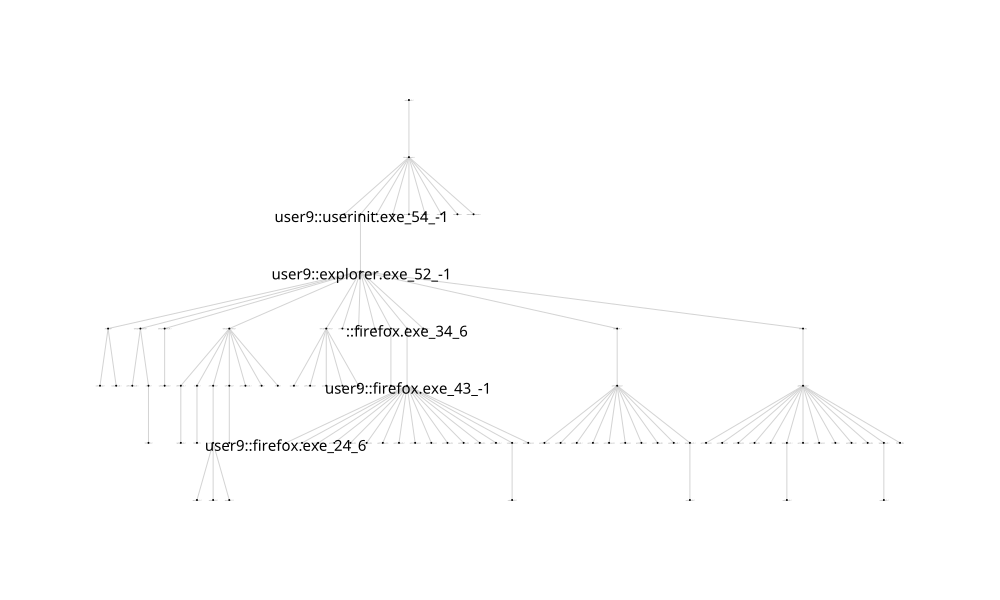

In [425]:
## plot reference tree (with baduser)
path = [int(x[0]) for x in paths]
sg1.vs['vertex_size'] = 1
sg1.vs['vertex_label_size'] = 1
for i in path:
    sg1.vs[i]['vertex_size'] = 1
    sg1.vs[i]['vertex_label_size'] = 15
ig.plot(sg1,
        bbox=(1000,600), layout=sg1['ly'], margin=100, 
        vertex_size=sg1.vs['vertex_size'], 
        vertex_label=sg1.vs['enriched_label'], 
        vertex_label_size=sg1.vs['vertex_label_size'], 
        edge_color='lightgrey', edge_arrow_size=0)


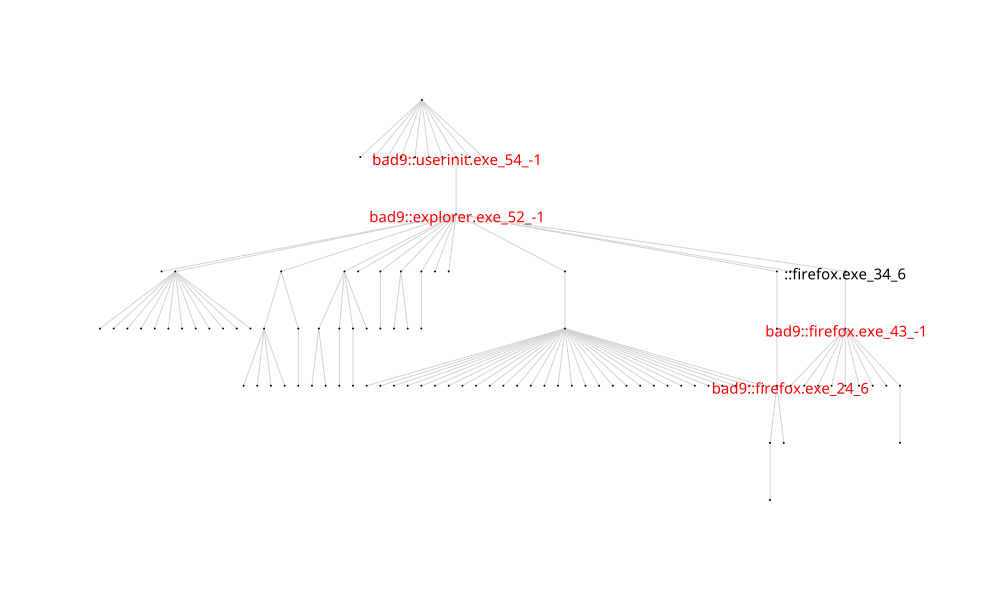

In [426]:
## plot top scoring tree
path = [int(x[1]) for x in paths]
sg2.vs['vertex_size'] = 1
sg2.vs['vertex_label_size'] = 0
for i in path:
    sg2.vs[i]['vertex_size'] = 1
    sg2.vs[i]['vertex_label_size'] = 15
ig.plot(sg2,
        bbox=(1000,600), layout=sg2['ly'], margin=100, 
        vertex_size=sg2.vs['vertex_size'], 
        vertex_label=sg2.vs['enriched_label'], 
        vertex_label_size=sg2.vs['vertex_label_size'], 
        edge_color='lightgrey', edge_arrow_size=0)


In [348]:
other_roots[135]

KeyError: 135

In [300]:
### EDA

In [301]:
G.vs[0]

igraph.Vertex(<igraph.Graph object at 0x75425f511550>, 0, {'name': np.int64(2021863), 'pid': '6DA116CF30116D13D73F0176C88FE8FA', 'username': None, 'process': 'unknown', 'filemd5': None, 'time': 1725614398, 'label': '::unknown', 'shortlabel': '', 'label_color': 'black', 'color': 'black', 'tree': 0, 'tree_size': 24610, 'cluster': '43', 'enriched': 'unknown_-1', 'enriched_label': '::unknown_-1', 'bh': -1})

In [302]:
_ = pd.DataFrame(np.array([G.vs['process'], G.vs['bh'], G.vs['cluster']]).T, columns=['process','bh','embed'])

In [298]:
_[_.bh!='-1'].groupby(by='bh')['process'].value_counts()

bh  process                                  
0   dsregcmd.exe                                    648
1   ngen.exe                                       1961
    mscorsvw.exe                                   1065
    ngentask.exe                                    440
    taskhostw.exe                                   223
10  wintapsvcmgr.exe                                975
11  runtimebroker.exe                                36
12  taskhostw.exe                                  3057
13  musnotification.exe                             194
    musnotificationux.exe                             1
14  searchapp.exe                                    71
15  microsoftedgeupdate.exe                        7049
    microsoftedgeupdatecomregistershell64.exe        15
16  sppsvc.exe                                     3766
17  svchost.exe                                    1401
18  mousocoreworker.exe                            6404
    tiworker.exe                                    989
  

In [296]:
_[_.bh!='-1'].groupby(by='process')['bh'].value_counts()

process                                    bh
backgroundtaskhost.exe                     8       1639
bash.exe                                   20       115
dsregcmd.exe                               0        648
firefox.exe                                6       6768
git.exe                                    20       917
mergehelper.exe                            7      61774
microsoftedgeupdate.exe                    15      7049
microsoftedgeupdatecomregistershell64.exe  15        15
mousocoreworker.exe                        18      6404
mscorsvw.exe                               1       1065
                                           3        209
musnotification.exe                        13       194
musnotificationux.exe                      13         1
ngen.exe                                   1       1961
ngentask.exe                               1        440
powershell.exe                             21      1311
runtimebroker.exe                          11        36
se

In [304]:
_[_.bh!='-1'].groupby(by='bh')['embed'].value_counts()

bh  embed
0   59       320
    44        91
    40        72
    21        64
    50        52
            ... 
9   49         6
    54         4
    4          3
    16         1
    42         1
Name: count, Length: 465, dtype: int64